In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
df = pd.read_csv("Mental_Health_Clean_Final.csv")

# verificar las primeras filas del DataFrame y la información general del mismo
display(df.head())
df.info()


,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,09/16/2020,09/28/2020,6.9,6.5,7.3
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,09/16/2020,09/28/2020,11.0,10.4,11.6
2,Took Prescription Medication for Mental Health...,National Estimate,United States,United States,2,13,08/19/2020,08/31/2020,19.4,19.0,19.8
3,Took Prescription Medication for Mental Health...,By Age,United States,18 - 29 years,2,13,08/19/2020,08/31/2020,18.7,17.2,20.3
4,Took Prescription Medication for Mental Health...,By Age,United States,30 - 39 years,2,13,08/19/2020,08/31/2020,18.3,17.3,19.2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Indicator               9914 non-null   object 
 1   Group                   9914 non-null   object 
 2   State                   9914 non-null   object 
 3   Subgroup                9914 non-null   object 
 4   Phase                   9914 non-null   object 
 5   Time Period             9914 non-null   int64  
 6   Time Period Start Date  9914 non-null   object 
 7   Time Period End Date    9914 non-null   object 
 8   Value                   9914 non-null   float64
 9   LowCI                   9914 non-null   float64
 10  HighCI                  9914 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 852.1+ KB


## 1. Comprensión Teórica

Para llevar a cabo un análisis sistemático y justificado comenzaremos definiendo los conceptos teóricos de la estadística descriptiva y su relevancia específica para nuestro conjunto de datos sobre Salud Mental.

### Medidas de Tendencia Central
Las medidas de tendencia central nos ayudan a encontrar el valor "típico" o central alrededor del cual se agrupan nuestros datos.
*   **Media (Promedio):** Es la suma de todos los valores dividida por el número de observaciones.
 * *Relevancia en el dataset:* Nos permitirá saber, en promedio, qué porcentaje de la población a nivel nacional reportó síntomas o buscó tratamiento.
*   **Mediana:** El valor central cuando los datos están ordenados.
* *Relevancia:* Es crucial porque es menos sensible a valores atípicos (outliers) que la media. Si un estado o grupo demográfico tiene porcentajes inusualmente altos (por ejemplo, el subgrupo "Transgender" muestra valores superiores al 50% en consumo de medicamentos), la mediana nos dará una mejor representación del centro general.

### Medidas de Dispersión
Nos indican qué tan extendidos o dispersos están los datos respecto al centro.
*   **Desviación Estándar:** Mide la cantidad promedio que los valores se desvían de la media.
 * *Relevancia:* Una desviación estándar alta en la variable `Value` (porcentaje) para un indicador específico significaría que hay una gran desigualdad en la salud mental entre diferentes estados o grupos demográficos.
*   **Mínimo, Máximo y Rango:**
* *Relevancia:* Nos permite ver los extremos. Por ejemplo, ver que el porcentaje de personas de 80 años o más que "Necesitaron terapia pero no la obtuvieron" puede llegar a ser tan bajo como 1.4%, mientras que otros subgrupos son mucho más alto

In [9]:
#Calcularemos las métricas de tendencia central y dispersión para las variables numéricas (`Value`, `LowCI`, `HighCI`).
desc_stats = df[['Value', 'LowCI', 'HighCI']].describe()
display(desc_stats)

# Calculamos explícitamente la varianza
variance = df[['Value', 'LowCI', 'HighCI']].var()
print("\nVarianza de las variables numéricas:")
print(variance)

,Value,LowCI,HighCI
count,9914.000000,9914.000000,9914.000000
mean,17.450736,14.771565,20.475661
std,8.270565,7.659396,9.052521
min,1.400000,0.800000,2.000000
25%,10.300000,8.000000,12.900000
50%,16.200000,13.900000,19.200000
75%,24.000000,20.800000,27.400000
max,62.900000,53.200000,71.900000



Varianza de las variables numéricas:
Value     68.402248
LowCI     58.666347
HighCI    81.948141
dtype: float64


La media de la columna `Value` nos dirá el promedio general de todas las mediciones de salud mental, pero al mezclar indicadores distintos, la desviación estándar y la varianza serán altas. Para tener un análisis preciso, debemos agrupar los datos por sus entidades, como lo solicita la práctica.
Para entender realmente los datos, agruparemos por la entidad **`Indicator`** y **`Group`**. Esto nos permitirá comparar el comportamiento de la salud mental.


In [10]:
grouped_indicator = df.groupby('Indicator')['Value'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
grouped_indicator.columns = ['Conteo', 'Media', 'Mediana', 'Desv_Estandar', 'Mínimo', 'Máximo']
print("Estadísticas de 'Value' agrupadas por Indicador:")
display(grouped_indicator)

# Estadísticas agrupadas por 'Group' (Entidad Demografía) para ver el impacto por tipo de grupo
grouped_demographics = df.groupby('Group')['Value'].agg(['mean', 'median', 'std'])
grouped_demographics = grouped_demographics.sort_values(by='mean', ascending=False)
print("\nEstadísticas de 'Value' agrupadas por Categoría Demográfica:")
display(grouped_demographics)

Estadísticas de 'Value' agrupadas por Indicador:


,Conteo,Media,Mediana,Desv_Estandar,Mínimo,Máximo
Indicator,,,,,,
"Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks",2470,11.201984,10.7,4.412068,1.4,51.5
"Received Counseling or Therapy, Last 4 Weeks",2476,10.460743,10.0,3.832306,1.4,45.7
"Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks",2484,25.782327,25.7,5.633031,10.3,62.9
"Took Prescription Medication for Mental Health, Last 4 Weeks",2484,22.300161,22.1,5.179210,7.3,54.7



Estadísticas de 'Value' agrupadas por Categoría Demográfica:


,mean,median,std
Group,,,
By Sexual orientation,26.588889,24.75,11.293857
By Gender identity,25.962500,23.25,15.156913
By Disability status,23.915972,21.10,13.157660
By Presence of Symptoms of Anxiety/Depression,19.979545,17.45,12.645477
By State,17.384040,16.10,7.661665
National Estimate,16.809091,15.90,6.500681
By Sex,16.648106,14.40,7.814275
By Education,16.395644,15.05,6.698843
By Age,15.960263,16.90,7.716940


Al agrupar por indicador, notamos diferencias claras entre la media y la mediana. Por ejemplo, para los indicadores como "Took Prescription Medication for Mental Health" y "Needed Counseling or Therapy But Did Not Get It", la desviación estándar nos mostrará qué tanto varía el acceso a medicamentos o terapias entre los diferentes subgrupos y estados a lo largo de la pandemia.


### 1. Histograma y Boxplot (Medidas de Dispersión y Outliers)
Mostraremos la distribucion por indicador, de esta manera podremos observar a detalle cada indicador en la poblacion global, podremos determinar que indice de poblacion necesitaba medicamentos o que personas fueron las que recibieron mas consultorias e ingerir medicamentos para ello
.

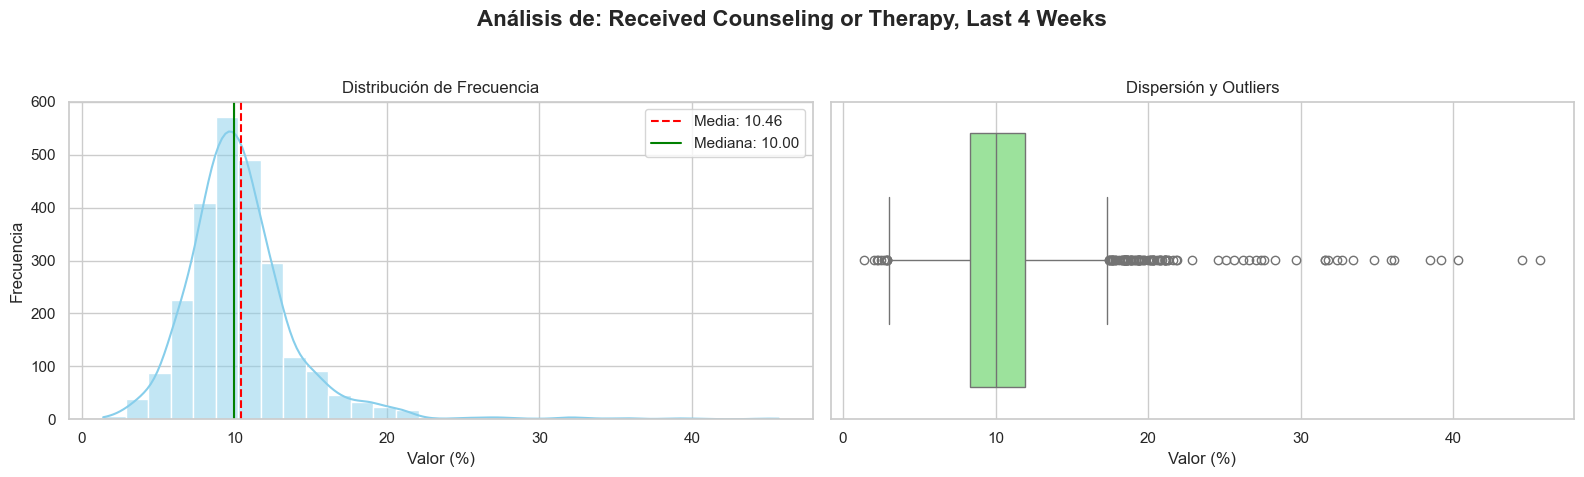

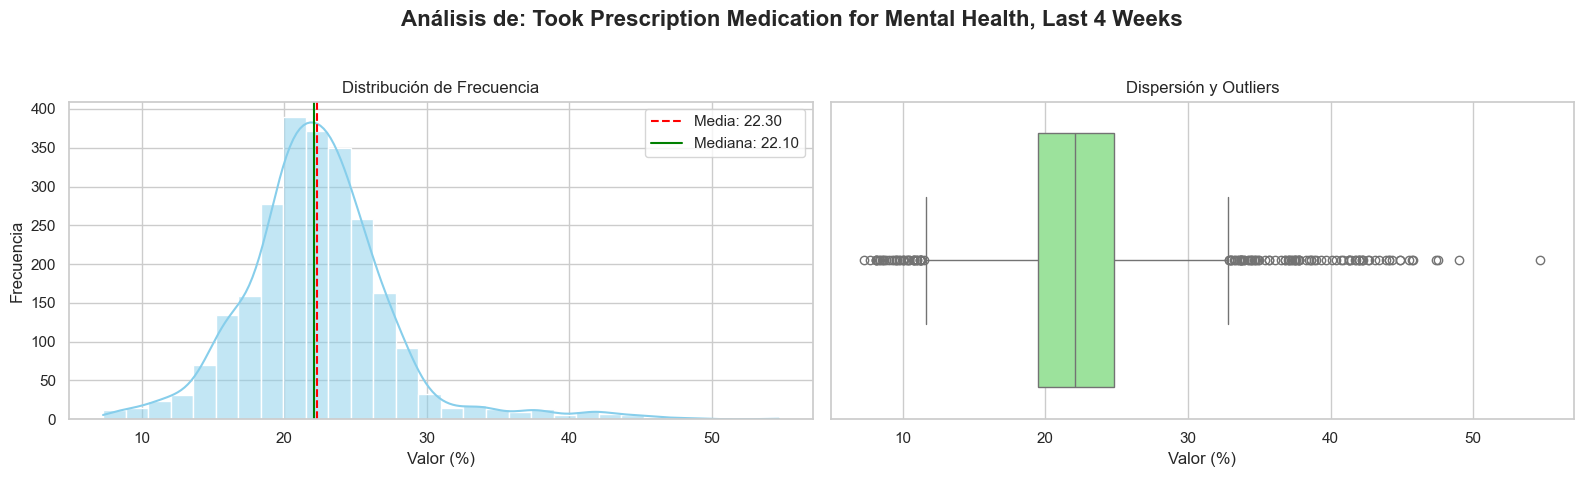

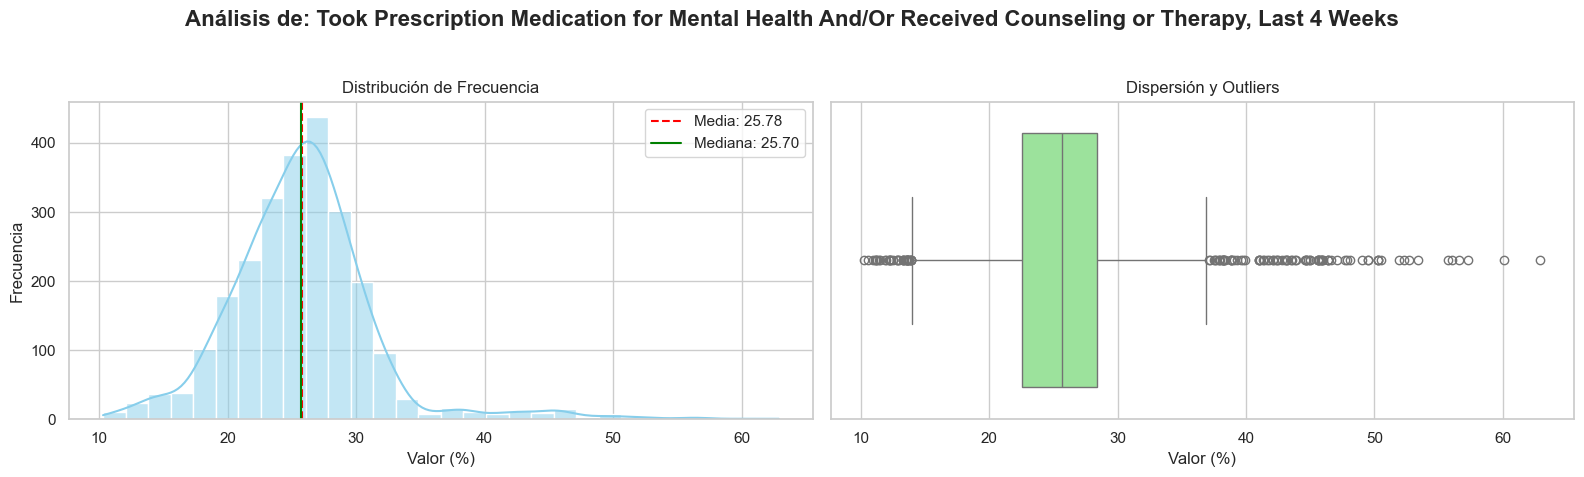

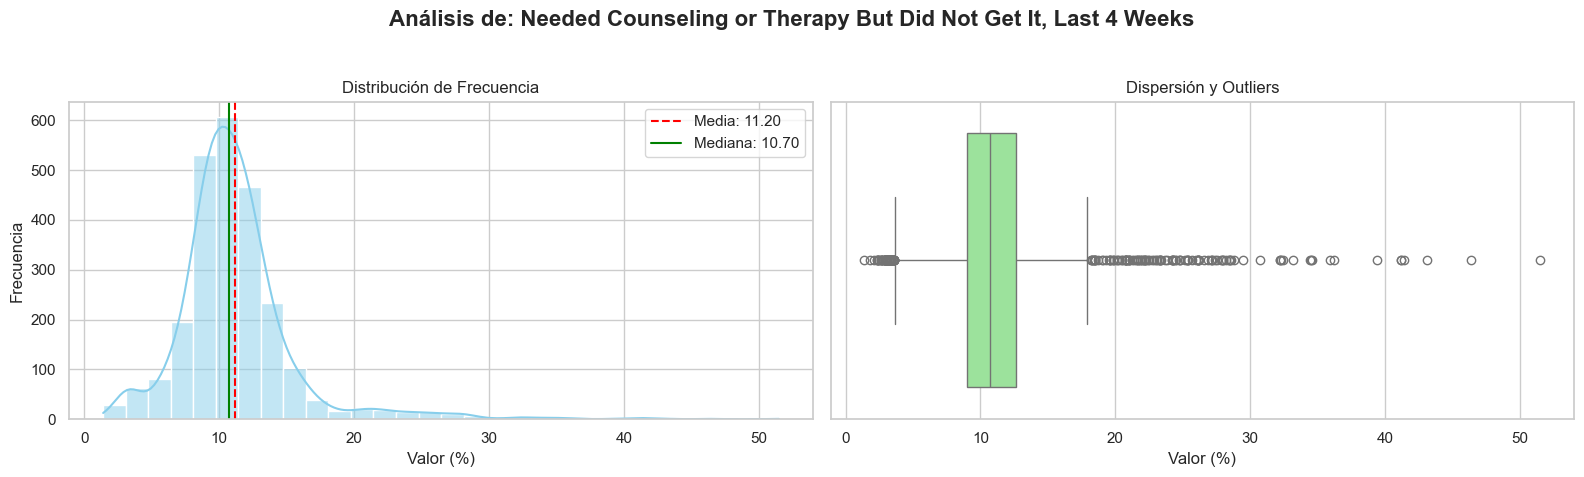

In [ ]:
indicadores = df['Indicator'].unique()

# Iterar sobre cada indicador para crear gráficos separados
for ind in indicadores:
    # Filtrar el DataFrame por el indicador actual
    data_filtrada = df[df['Indicator'] == ind]
    
    # Crear la figura con 2 columnas
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Título principal para la figura completa
    fig.suptitle(f'Análisis de: {ind}', fontsize=16, fontweight='bold')
    
    # Histograma (axes[0])
    sns.histplot(data_filtrada['Value'].dropna(), bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribución de Frecuencia')
    axes[0].set_xlabel('Valor (%)')
    axes[0].set_ylabel('Frecuencia')
    
    # Agregar líneas de media y mediana
    media = data_filtrada['Value'].mean()
    mediana = data_filtrada['Value'].median()
    axes[0].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[0].axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
    axes[0].legend()
    
    # Boxplot (axes[1])
    sns.boxplot(x=data_filtrada['Value'], ax=axes[1], color='lightgreen')
    axes[1].set_title('Dispersión y Outliers')
    axes[1].set_xlabel('Valor (%)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()